In [1]:
import os
import time
import shutil
from datetime import datetime
from PIL import Image
from IPython.display import display, Image as IPImage

# Google Generative AI components
import google.generativeai as genai

# --- CONFIGURATION ---
KEY_FILE = "gemini_key.txt"
BASE_DIR = "questionnaire_icons"
RAW_DIR = os.path.join(BASE_DIR, "raw")
OLD_IMAGE_DIR = os.path.join(BASE_DIR, "old_images")
SKIP_EXISTING = True 
RPM_LIMIT = 10        
SLEEP_TIME = 60 / RPM_LIMIT

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(OLD_IMAGE_DIR, exist_ok=True)

with open(KEY_FILE, "r") as f:
    api_key = f.read().strip()

genai.configure(api_key=api_key)
# Ensure the model matches what is available in your GCP console
model = genai.GenerativeModel('gemini-2.5-flash-image') 
print("Setup complete. Directories created and API initialized.")

Setup complete. Directories created and API initialized.


c:\Users\trevo\research\VHPlatform_icon_gen\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\trevo\AppData\Local\Temp\ipykernel_13824\2630551096.py:9: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
def apply_grey_processing(raw_filepath, final_filepath, bg_color=(220, 220, 220)):
    """
    Applies the procedural grey background to the B&W raw generation.
    Saves as a flat JPG with no rounded corners.
    """
    # Raw is prompted to be a black background with a white silhouette
    raw_img = Image.open(raw_filepath).convert("L")
    
    # Solid background and solid white icon layers
    bg_layer = Image.new("RGB", raw_img.size, bg_color)
    icon_layer = Image.new("RGB", raw_img.size, (255, 255, 255))
    
    # Composite using raw_img as the alpha mask. 
    # White areas of raw_img take from icon_layer; black areas take from bg_layer.
    final_img = Image.composite(icon_layer, bg_layer, raw_img)
    final_img.save(final_filepath, "JPEG", quality=95)

def generate_icon(filename, subject, variant_suffix="", skip_existing=True):
    full_name = f"{filename}{variant_suffix}"
    raw_filepath = os.path.join(RAW_DIR, f"{full_name}_raw.png")
    final_filepath = os.path.join(BASE_DIR, f"{full_name}.jpg")
    
    if os.path.exists(final_filepath):
        if skip_existing:
            return None
        else:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            shutil.move(final_filepath, os.path.join(OLD_IMAGE_DIR, f"{timestamp}_{full_name}.jpg"))
            if os.path.exists(raw_filepath):
                shutil.move(raw_filepath, os.path.join(OLD_IMAGE_DIR, f"{timestamp}_{full_name}_raw.png"))

    prompt = (f"A solid white silhouette, centered, pure black background, "
              f"minimalist flat vector icon, no fine lines, high contrast of "
              f"'{subject}'. No text, no shading.")

    try:
        response = model.generate_content(prompt, generation_config={"response_modalities": ["IMAGE"]})
        for part in response.candidates[0].content.parts:
            if hasattr(part, 'inline_data') and part.inline_data.data:
                # Save raw B&W PNG
                with open(raw_filepath, "wb") as f:
                    f.write(part.inline_data.data)
                
                # Apply procedural styling
                apply_grey_processing(raw_filepath, final_filepath)
                return final_filepath
    except Exception as e:
        print(f"API Error for {full_name}: {e}")
    
    return None

In [ ]:
## {"filename": "", "prompt": ""},

icons_to_generate = [
    {"filename": "visual", "prompt": "A simple open eye"},
    {"filename": "auditory", "prompt": "A minimalist ear profile"},
    {"filename": "smell", "prompt": "A stylized nose profile"},
    {"filename": "time", "prompt": "a simple clock face"},
    {"filename": "taste", "prompt": "A simple tongue profile"},
    {"filename": "physicalSensations", "prompt": "a simple icon of a hand"},
    {"filename": "sense of body", "prompt": "a simple human figure standing upright in the style of the signs on restroom doors"},
    {"filename": "self", "prompt": "a simple icon of an empty mirror"},
    {"filename": "geometric", "prompt": "a simple icon of scattered shapes and lines"},
    {"filename": "semantic", "prompt": "a simple icon of a landscape with a tree and a person standing"},
    {"filename": "distortions", "prompt": "an image of a figure which has been spatially warped"},
    {"filename": "phosphenes", "prompt": "a simple icon of visaul noise, lots of dots"},
    {"filename": "symbols", "prompt": "an icon showing a scattering of a few random symbols in different styles, including a letter, a number, a musical note, and an abstract symbol which looks plausibly like a real symbol but is from no real language"},
    {"filename": "directionalMovement", "prompt": "arrows pointing all in one diagonal direction"},
    {"filename": "rotational movement", "prompt": "arrows pointing arounnd in a circle"},
    {"filename": "zooming movement", "prompt": "arrows pointing inwards and outwards towards the centre of the image"},
    {"filename": "chaotic movement", "prompt": "arrows pointing in various directions randomly"},
    {"filename": "ringing", "prompt": "a simple icon for rining sound, one dot with ringing semicirles eminating from it"},
    {"filename": "music", "prompt": "musical notes"},
    {"filename": "buzzing", "prompt": "a simple icon for buzzing sound, one dot with buzzing zigzag lines eminating from it"},
    {"filename": "white noise", "prompt": "a simple icon for white noise, a dot with lots of small dots eminating from it"},
    {"filename": "voices", "prompt": "a simple icon for voices, a dot with small speech bubbles eminating from it"},
]

Starting generation for 4 icons...
Generated: questionnaire_icons\visual_experiences.jpg


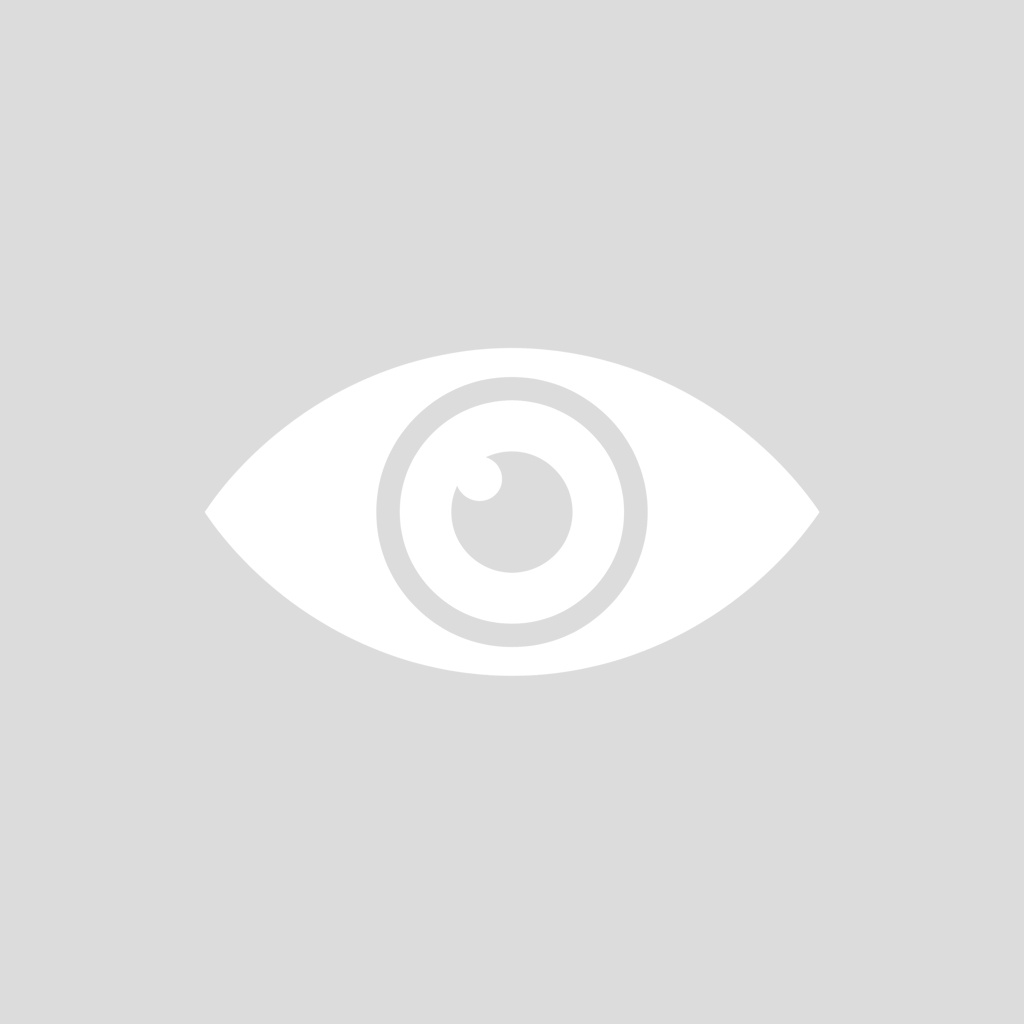

Generated: questionnaire_icons\auditory_experiences.jpg


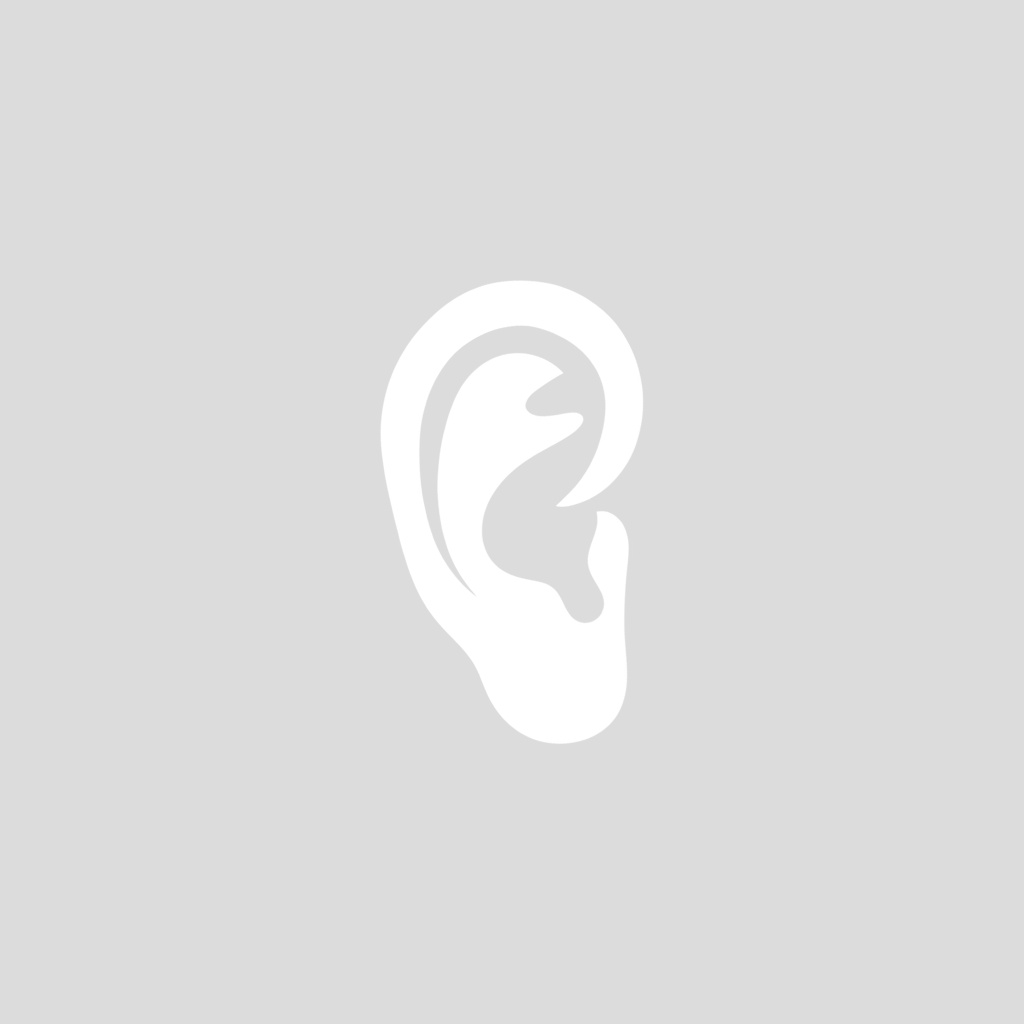

Generated: questionnaire_icons\olfactory_responses.jpg


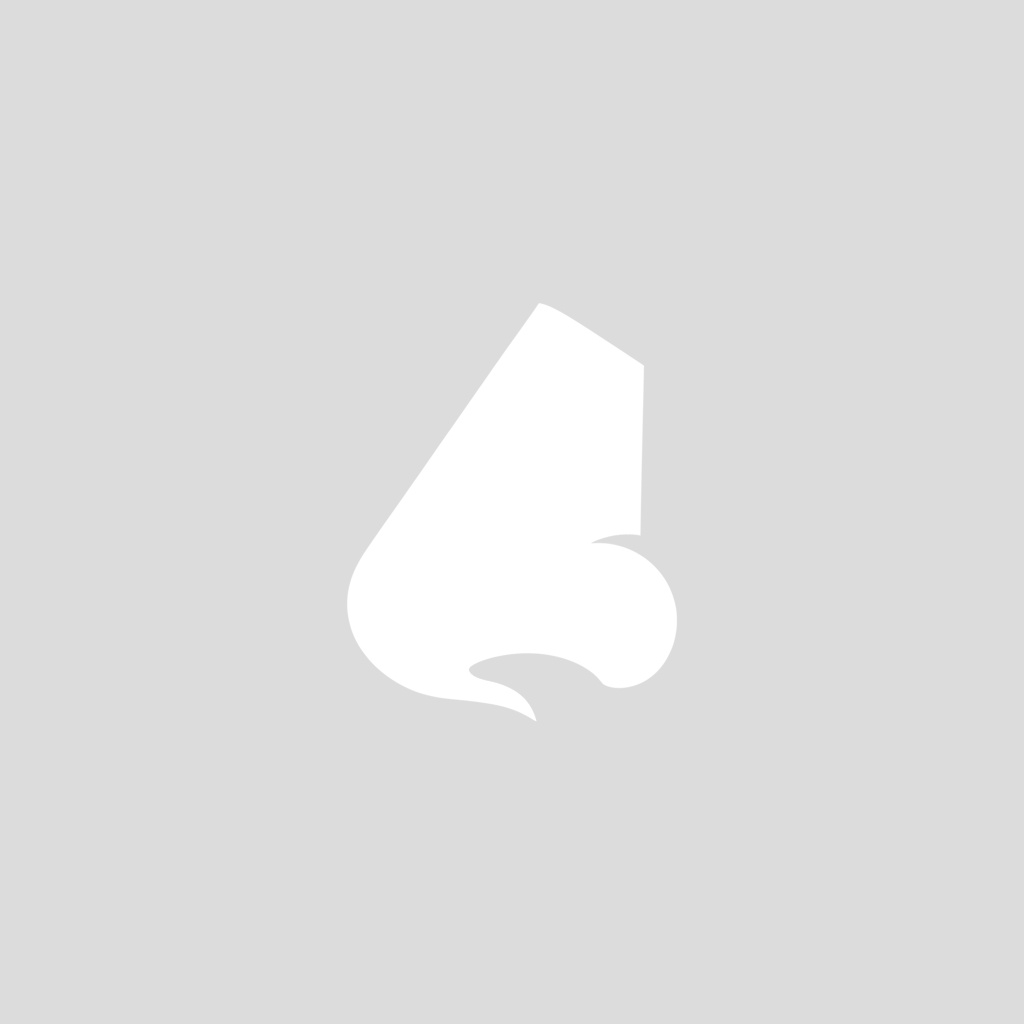

Generated: questionnaire_icons\senseOfTime.jpg


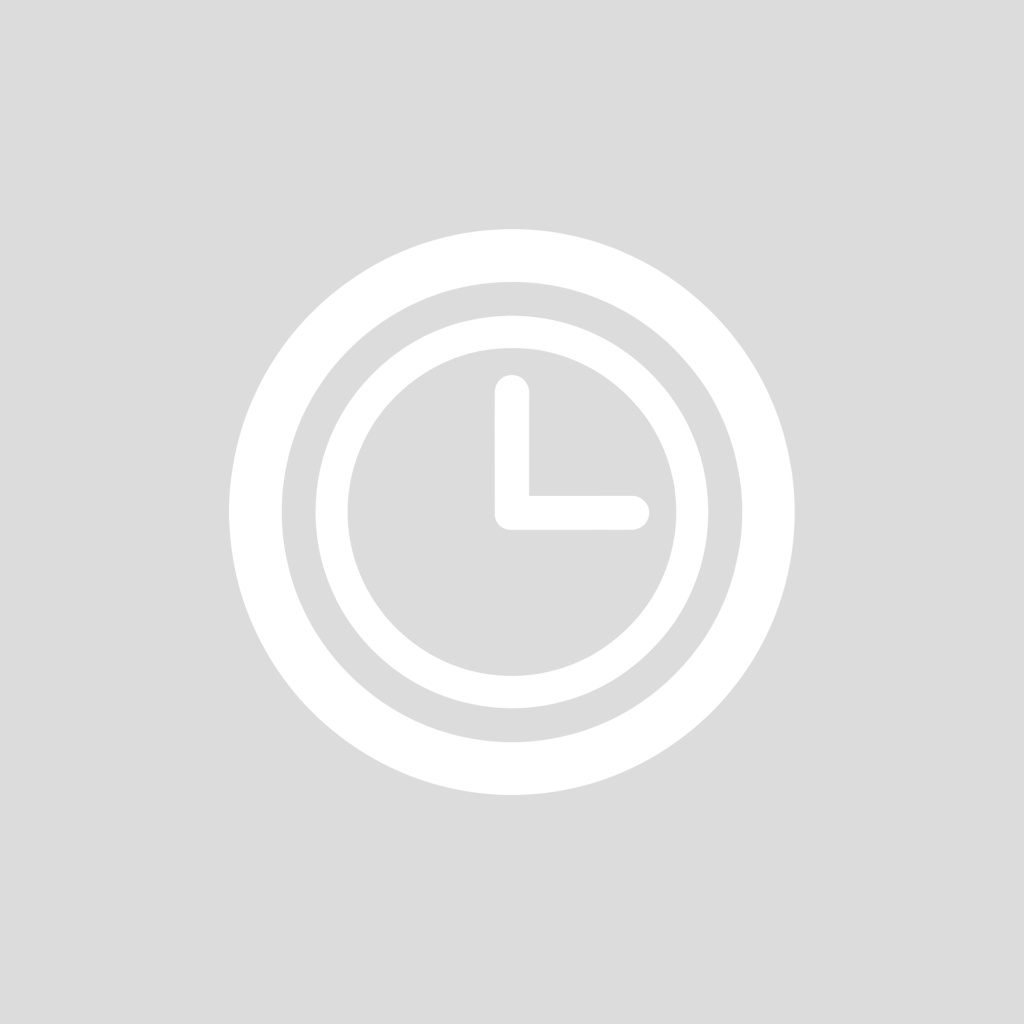

Initial processing complete.


In [4]:
print(f"Starting generation for {len(icons_to_generate)} icons...")

for item in icons_to_generate:
    filename = item["filename"]
    prompt = item["prompt"]
    
    path = generate_icon(filename, prompt, skip_existing=SKIP_EXISTING)
    
    if path:
        print(f"Generated: {path}")
        display(IPImage(filename=path, width=150))
        time.sleep(SLEEP_TIME)

print("Initial processing complete.")